In [ ]:
# Binary classification problem

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# create a dataset
data = {
    'Glucose': [85, 89, 120, 150, 95, 140],
    'BMI': [26.6, 28.1, 32.0, 34.2, 27.5, 33.1],
    'Age': [29, 31, 45, 50, 35, 48],
    'Diabetes': [0, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

x = df[['Glucose','BMI','Age']]

y = df['Diabetes']

# train_test_split

x_train, x_test , y_train, y_test = train_test_split (x, y, test_size = 0.3, random_state = 42)


# fit model

model = LogisticRegression()
model.fit(x_train, y_train)

# predictions

y_pred = model.predict(x_test)

# Evaluation

print("logistic Regression;",y_pred)
print("accuracy_score:\n",accuracy_score(y_test, y_pred))
print("coufusion_matrix:\n", confusion_matrix (y_test, y_pred, labels = [0, 1]))
print("classification_report:\n",classification_report(y_test, y_pred))


#new patient

new_patient = pd.DataFrame([[110, 29.1, 30]], columns = ['Glucose','BMI','Age'])

prob = model.predict_proba(new_patient)
print("new patient:", prob)



logistic Regression; [0 0]
accuracy_score:
 1.0
coufusion_matrix:
 [[2 0]
 [0 0]]
classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

new patient: [[0.61725362 0.38274638]]


In [ ]:
# Loan approved or Not

logistic_regression:  [1 1]
accuracy_score: 
 0.5
confusion_matrix: 
 [[0 1]
 [0 1]]
classification_report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

approval probalility:  5.897715539978291e-12
loan_approved 1=[yes], 0=[No]: 0


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


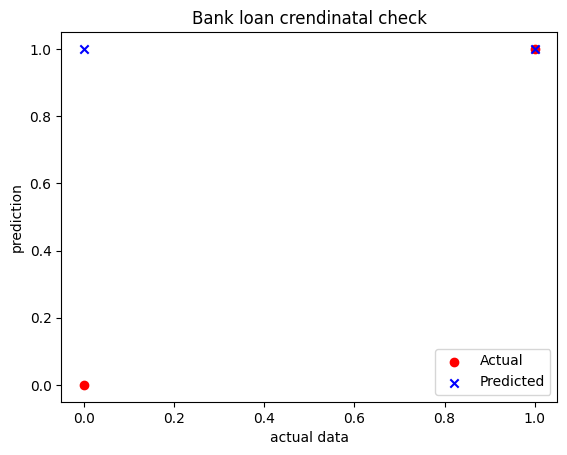

AUC Score: 1.0


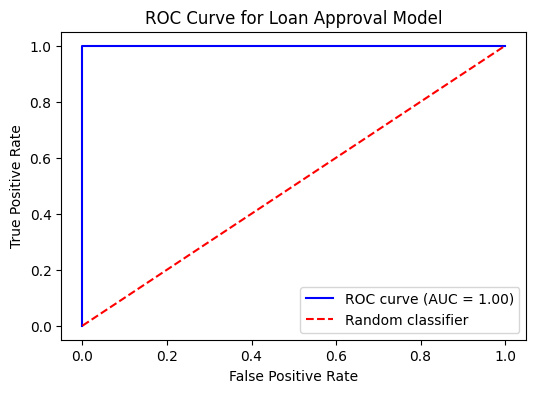

In [25]:
# import libaries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
from sklearn.preprocessing import StandardScaler

# create dataset

data = {
    'Income': [50000, 30000, 80000, 25000, 60000],
    'Credit_Score': [720, 650, 780, 600, 700],
    'Loan_Amount': [200000, 150000, 300000, 100000, 250000],
    'Employment_Years': [5, 2, 8, 1, 4],
    'Loan_Approved': [1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

x = df[['Income','Credit_Score', 'Loan_Amount','Employment_Years']]

y = df['Loan_Approved']

# scaling  feature

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)


# train the data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# fit the model

model = LogisticRegression()
model.fit(x_train, y_train)

# prediction

y_pred =  model.predict(x_test)

# Elevation

print("logistic_regression: ", y_pred)
print("accuracy_score: \n", accuracy_score(y_test, y_pred))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred))
print("classification_report: \n", classification_report(y_test, y_pred))

# New coustomer

new_coustomer = pd.DataFrame([[35000, 725, 50000, 3.5]],
                             columns = ['Income','Credit_Score', 'Loan_Amount','Employment_Years'])
new_customer_scaled = scaler.transform(new_coustomer)
x_prob = model.predict_proba(new_coustomer)
x_pred = model.predict(new_coustomer)

print("approval probalility: ", x_prob[0][1])
print("loan_approved 1=[yes], 0=[No]:",x_pred[0])


# visulization

plt.scatter(range(len(y_test)), y_test, color="red", label="Actual")
plt.scatter(range(len(y_pred)), y_pred, color="blue", marker="x", label="Predicted")
plt.xlabel("actual data")
plt.ylabel("prediction")
plt.title("Bank loan crendinatal check")
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities for test set
y_prob = model.predict_proba(x_test)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Loan Approval Model")
plt.legend()
plt.show()

In [ ]:
# spam mail  detection

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,  classification_report

# create a dataset

data = {
    "email": [
        "Win a free iPhone now",
        "Limited offer buy now",
        "Congratulations you won lottery",
        "Earn money from home",
        "Meeting scheduled at 10am",
        "Please review the project report",
        "Let's have lunch tomorrow",
        "Team meeting postponed",
        "Claim your cash prize now",
        "Urgent offer ends today"
    ],
    "spam" : [1, 1, 1, 1, 0, 0, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

x = df["email"]

y = df["spam"]


# train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# vectorzier

vectorizer = TfidfVectorizer(stop_words = "english")

x_train_vec = vectorizer.fit_transform(x_train)

x_test_vec = vectorizer.transform(x_test)

# train logistic regression

model = LogisticRegression()

model.fit(x_train_vec, y_train)

# prediction

pred = model.predict(x_test_vec )

# elecvation

print("spam or not",pred)
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))



spam or not [1 1]
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
# Multi-class classification 

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# create a data

x = np.array([
    [4, 30, 25],   # Cat
    [5, 35, 28],   # Cat
    [6, 40, 30],   # Dog
    [20, 60, 40],  # Dog
    [25, 70, 45],  # Dog
    [1, 15, 5],    # Bird
    [1.2, 18, 6],  # Bird
    [0.8, 12, 4]   # Bird
])

# Labels
y = np.array([
    "Cat", "Cat",
    "Dog", "Dog", "Dog",
    "Bird", "Bird", "Bird"
])

# encoder class labels to convert string into numbers

le = LabelEncoder()

le_pre = le.fit_transform(y)

print(le.classes_)

# train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, le_pre, test_size = 0.2, random_state = 42)

# fit logistic regression

model = LogisticRegression()

model.fit(x_train, y_train)

# prediction

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)

# Elevation

print("animals = 0->bird, 1->cat, 2-> dog:", y_pred)
print("probaility:", y_prob[0])
print(" accuracy_score :\n", accuracy_score(y_test, y_pred))
print("classification_report:\n", classification_report(y_test, y_pred))


#new animal 

new_animal = np.array([[8, 37, 40]])

pre = model.predict(new_animal)

print("new unkown animal:", le.inverse_transform(pre))


['Bird' 'Cat' 'Dog']
animals = 0->bird, 1->cat, 2-> dog: [2 0]
probaility: [0.00187898 0.48632847 0.51179256]
 accuracy_score :
 0.5
classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.33      0.33      0.33         2
weighted avg       0.50      0.50      0.50         2

new unkown animal: ['Dog']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklea